# DDPM on EMNIST (TensorFlow)

TensorFlow/Keras port of the PyTorch DDPM notebook: trains a small time-conditioned U-Net to
predict noise on EMNIST "letters", runs full reverse diffusion, and evaluates PSNR/SSIM against
real images.

In [1]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric


In [2]:
IMG_SIZE = 32           # EMNIST is 28x28; resize to 32x32 (divisible by 8)
BATCH_SIZE = 128
EPOCHS = 10              # bump up for better sample quality
LR = 2e-4
T = 200                  # total diffusion timesteps (per the assignment)
BASE_CH = 32
OUT_DIR = "./outputs_ddpm"
os.makedirs(OUT_DIR, exist_ok=True)
SNAPSHOT_STEPS = [200, 150, 100, 50, 0]

tf.random.set_seed(0)
np.random.seed(0)


## Data loading

EMNIST's "letters" split is stored rotated/transposed relative to its natural reading
orientation (a well-known quirk of the original dataset format) — the same fix applied in the
PyTorch version (`rotate(-90)` + horizontal flip) is reproduced here with `tf.image` ops.

In [3]:
def fix_emnist_orientation(img):
    # equivalent of PIL's img.rotate(-90).transpose(FLIP_LEFT_RIGHT)
    img = tf.image.rot90(img, k=3)          # rotate -90 degrees
    img = tf.image.flip_left_right(img)     # transpose(0) == FLIP_LEFT_RIGHT
    return img

def preprocess(example, img_size=IMG_SIZE):
    img = tf.cast(example["image"], tf.float32) / 255.0   # -> [0, 1]
    img = fix_emnist_orientation(img)
    img = tf.image.resize(img, (img_size, img_size))
    img = img * 2.0 - 1.0                                  # -> [-1, 1]
    return img

def get_dataset(batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    ds = tfds.load("emnist/letters", split="train", as_supervised=False)
    ds_images = ds.map(lambda ex: preprocess(ex, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = (ds_images
                .shuffle(10000)
                .batch(batch_size, drop_remainder=True)
                .prefetch(tf.data.AUTOTUNE))
    # a plain (unbatched) copy for later "grab a few real images" use
    return train_ds, ds_images


## Model: sinusoidal time embedding + residual U-Net

In [4]:
class SinusoidalTimeEmbedding(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def call(self, t):
        t = tf.cast(t, tf.float32)
        half_dim = self.dim // 2
        freq = math.log(10000) / (half_dim - 1)
        freq = tf.exp(tf.range(half_dim, dtype=tf.float32) * -freq)
        args = t[:, None] * freq[None, :]
        emb = tf.concat([tf.sin(args), tf.cos(args)], axis=-1)
        if self.dim % 2 == 1:
            emb = tf.pad(emb, [[0, 0], [0, 1]])
        return emb


class TimeMLP(tf.keras.layers.Layer):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(dim)
        self.fc1 = tf.keras.layers.Dense(out_dim)
        self.fc2 = tf.keras.layers.Dense(out_dim)

    def call(self, t):
        x = self.time_embed(t)
        x = self.fc1(x)
        x = tf.nn.silu(x)
        x = self.fc2(x)
        return x


class ResBlock(tf.keras.layers.Layer):
    def __init__(self, out_ch, time_dim):
        super().__init__()
        self.norm1 = tf.keras.layers.GroupNormalization(groups=8)
        self.conv1 = tf.keras.layers.Conv2D(out_ch, 3, padding="same")
        self.time_proj = tf.keras.layers.Dense(out_ch)
        self.norm2 = tf.keras.layers.GroupNormalization(groups=8)
        self.conv2 = tf.keras.layers.Conv2D(out_ch, 3, padding="same")
        self.out_ch = out_ch
        self.skip = None  # built lazily once we know in_ch

    def build(self, input_shape):
        in_ch = input_shape[-1]
        self.skip = (tf.keras.layers.Conv2D(self.out_ch, 1)
                     if in_ch != self.out_ch else tf.keras.layers.Activation("linear"))

    def call(self, x, t_emb, training=False):
        h = self.conv1(tf.nn.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, None, None, :]
        h = self.conv2(tf.nn.silu(self.norm2(h)))
        return h + self.skip(x)


class Down(tf.keras.layers.Layer):
    def __init__(self, out_ch, time_dim):
        super().__init__()
        self.block = ResBlock(out_ch, time_dim)
        self.pool = tf.keras.layers.Conv2D(out_ch, 4, strides=2, padding="same")

    def call(self, x, t_emb, training=False):
        h = self.block(x, t_emb, training=training)
        return self.pool(h), h


class Up(tf.keras.layers.Layer):
    def __init__(self, out_ch, time_dim):
        super().__init__()
        self.up = tf.keras.layers.Conv2DTranspose(out_ch, 4, strides=2, padding="same")
        self.block = ResBlock(out_ch, time_dim)

    def call(self, x, skip, t_emb, training=False):
        x = self.up(x)
        x = tf.concat([x, skip], axis=-1)
        return self.block(x, t_emb, training=training)


In [5]:
class SimpleUNet(tf.keras.Model):
    def __init__(self, in_ch=1, base_ch=BASE_CH, time_dim=256):
        super().__init__()
        self.time_mlp = TimeMLP(time_dim, time_dim)
        self.in_conv = tf.keras.layers.Conv2D(base_ch, 3, padding="same")

        self.down1 = Down(base_ch, time_dim)
        self.down2 = Down(base_ch * 2, time_dim)
        self.down3 = Down(base_ch * 4, time_dim)

        self.bottleneck1 = ResBlock(base_ch * 4, time_dim)
        self.bottleneck2 = ResBlock(base_ch * 4, time_dim)

        self.up3 = Up(base_ch * 2, time_dim)
        self.up2 = Up(base_ch, time_dim)
        self.up1 = Up(base_ch, time_dim)

        self.out_norm = tf.keras.layers.GroupNormalization(groups=8)
        self.out_conv = tf.keras.layers.Conv2D(in_ch, 3, padding="same")

    def call(self, x, t, training=False):
        t_emb = self.time_mlp(t)
        h = self.in_conv(x)

        d1, skip1 = self.down1(h, t_emb, training=training)
        d2, skip2 = self.down2(d1, t_emb, training=training)
        d3, skip3 = self.down3(d2, t_emb, training=training)

        b = self.bottleneck1(d3, t_emb, training=training)
        b = self.bottleneck2(b, t_emb, training=training)

        u3 = self.up3(b, skip3, t_emb, training=training)
        u2 = self.up2(u3, skip2, t_emb, training=training)
        u1 = self.up1(u2, skip1, t_emb, training=training)

        return self.out_conv(tf.nn.silu(self.out_norm(u1)))


## DDPM forward/reverse process

In [ ]:
class DDPM:
    def __init__(self, timesteps=T, beta_start=1e-4, beta_end=0.02):
        self.T = timesteps

        self.betas = tf.linspace(beta_start, beta_end, timesteps)
        self.betas = tf.cast(self.betas, tf.float32)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = tf.math.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = tf.concat([[1.0], self.alphas_cumprod[:-1]], axis=0)

        self.sqrt_alphas_cumprod = tf.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = tf.sqrt(1.0 - self.alphas_cumprod)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = tf.random.normal(tf.shape(x0))
        sqrt_ac = tf.reshape(tf.gather(self.sqrt_alphas_cumprod, t), (-1, 1, 1, 1))
        sqrt_1m_ac = tf.reshape(tf.gather(self.sqrt_one_minus_alphas_cumprod, t), (-1, 1, 1, 1))
        return sqrt_ac * x0 + sqrt_1m_ac * noise, noise

    def p_sample(self, model, x_t, t_index):
        batch_size = tf.shape(x_t)[0]
        t = tf.fill((batch_size,), t_index)

        predicted_noise = model(x_t, t, training=False)

        beta_t = self.betas[t_index]
        alpha_t = self.alphas[t_index]
        sqrt_1m_ac_t = self.sqrt_one_minus_alphas_cumprod[t_index]

        mean = (1.0 / tf.sqrt(alpha_t)) * (x_t - (beta_t / sqrt_1m_ac_t) * predicted_noise)

        if t_index == 0:
            return mean
        else:
            sigma_t = tf.sqrt(self.posterior_variance[t_index])
            z = tf.random.normal(tf.shape(x_t))
            return mean + sigma_t * z

    def sample(self, model, shape, snapshot_steps=None):
        x_t = tf.random.normal(shape)
        snapshots = {}
        snapshot_steps = set(snapshot_steps or [])

        if self.T in snapshot_steps:
            snapshots[self.T] = tf.identity(x_t)

        for t_index in reversed(range(self.T)):
            x_t = self.p_sample(model, x_t, t_index)
            if t_index in snapshot_steps:
                snapshots[t_index] = tf.identity(x_t)

        return x_t, snapshots


## Training loop

In [7]:
@tf.function
def train_step(model, optimizer, ddpm, images):
    batch_size = tf.shape(images)[0]
    # b. randomly sample a diffusion timestep per image in the batch
    t = tf.random.uniform((batch_size,), 0, ddpm.T, dtype=tf.int32)

    with tf.GradientTape() as tape:
        # forward-noise the images to x_t
        x_t, noise = ddpm.q_sample(images, t)
        # b. predict the noise with the U-Net
        predicted_noise = model(x_t, t, training=True)
        loss = tf.reduce_mean(tf.square(predicted_noise - noise))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train(model, ddpm, dataset, epochs=EPOCHS, lr=LR):
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr)
    losses = []

    for epoch in range(epochs):
        epoch_loss, n_batches = 0.0, 0
        for images in dataset:
            loss = train_step(model, optimizer, ddpm, images)
            epoch_loss += float(loss)
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f"Epoch [{epoch + 1}/{epochs}]  MSE Loss: {avg_loss:.4f}")

    return losses


## Plotting / visualization helpers

In [8]:
def plot_loss(losses, out_path=os.path.join(OUT_DIR, "ddpm_training_loss.png")):
    plt.figure(figsize=(7, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("DDPM Training Loss vs. Epoch")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved loss curve to {out_path}")


In [9]:
def to_display(img_tensor):
    img = tf.clip_by_value(img_tensor, -1, 1)
    img = (img + 1) / 2
    return img.numpy().squeeze(-1)   # drop the single channel dim for grayscale display


In [10]:
def visualize_denoising_steps(model, ddpm, n_rows=4,
                               out_path=os.path.join(OUT_DIR, "reverse_diffusion_steps.png")):
    final_images, snapshots = ddpm.sample(
        model, shape=(n_rows, IMG_SIZE, IMG_SIZE, 1), snapshot_steps=SNAPSHOT_STEPS)

    fig, axes = plt.subplots(n_rows, len(SNAPSHOT_STEPS),
                              figsize=(2.2 * len(SNAPSHOT_STEPS), 2.2 * n_rows))
    for row in range(n_rows):
        for col, step in enumerate(SNAPSHOT_STEPS):
            img = snapshots[step][row]
            ax = axes[row, col] if n_rows > 1 else axes[col]
            ax.imshow(to_display(img), cmap="gray")
            ax.axis("off")
            if row == 0:
                ax.set_title(f"t={step}")

    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved reverse-diffusion step visualization to {out_path}")
    return final_images


In [11]:
def compare_with_real(generated_images, real_ds, n_samples=4,
                       out_path=os.path.join(OUT_DIR, "generated_vs_real.png")):
    real_images = tf.stack([img for img in real_ds.take(n_samples)])

    fig, axes = plt.subplots(2, n_samples, figsize=(2.2 * n_samples, 4.4))
    for i in range(n_samples):
        axes[0, i].imshow(to_display(generated_images[i]), cmap="gray")
        axes[0, i].set_title("Generated")
        axes[0, i].axis("off")

        axes[1, i].imshow(to_display(real_images[i]), cmap="gray")
        axes[1, i].set_title("Real")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved generated-vs-real comparison to {out_path}")
    return real_images


In [12]:
def evaluate_psnr_ssim(generated_images, real_images):
    n = min(len(generated_images), len(real_images))
    psnr_scores, ssim_scores = [], []

    for i in range(n):
        gen = to_display(generated_images[i])
        real = to_display(real_images[i])

        psnr_val = psnr_metric(real, gen, data_range=1.0)
        ssim_val = ssim_metric(real, gen, data_range=1.0)

        psnr_scores.append(psnr_val)
        ssim_scores.append(ssim_val)

    avg_psnr = float(np.mean(psnr_scores))
    avg_ssim = float(np.mean(ssim_scores))

    print(f"Average PSNR: {avg_psnr:.3f} dB")
    print(f"Average SSIM: {avg_ssim:.3f}")
    return avg_psnr, avg_ssim


## Run everything

In [13]:
train_ds, real_images_ds = get_dataset()


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [00:00<00:00, 63.94 url/s]
Extraction completed...: 0 file [00:00, ? file/s]
Extraction completed...: 100%|██████████| 4/4 [00:00<00:00,  7.48 file/s]
                                                                        

Dataset emnist downloaded and prepared to C:\Users\Reaper\tensorflow_datasets\emnist\letters\3.1.0. Subsequent calls will reuse this data.


In [14]:
model = SimpleUNet(in_ch=1)
ddpm = DDPM(timesteps=T)


Epoch [1/10]  MSE Loss: 0.1415
Epoch [2/10]  MSE Loss: 0.0680
Epoch [3/10]  MSE Loss: 0.0597
Epoch [4/10]  MSE Loss: 0.0537
Epoch [5/10]  MSE Loss: 0.0505
Epoch [6/10]  MSE Loss: 0.0474
Epoch [7/10]  MSE Loss: 0.0455
Epoch [8/10]  MSE Loss: 0.0442
Epoch [9/10]  MSE Loss: 0.0430
Epoch [10/10]  MSE Loss: 0.0419


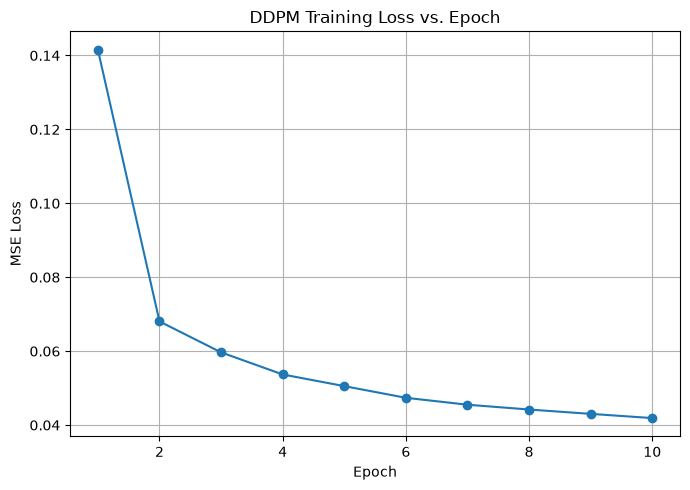

Saved loss curve to ./outputs_ddpm\ddpm_training_loss.png


In [15]:
losses = train(model, ddpm, train_ds)
plot_loss(losses)


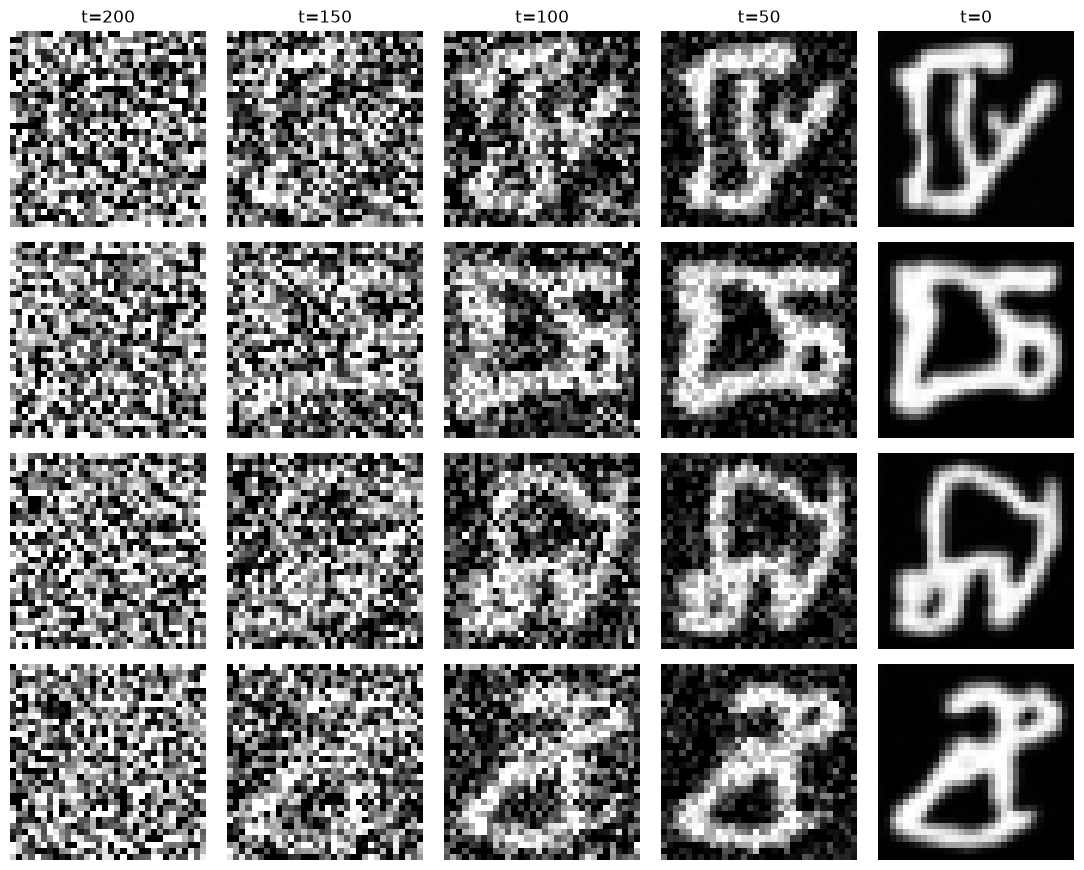

Saved reverse-diffusion step visualization to ./outputs_ddpm\reverse_diffusion_steps.png


In [16]:
generated_images = visualize_denoising_steps(model, ddpm, n_rows=4)


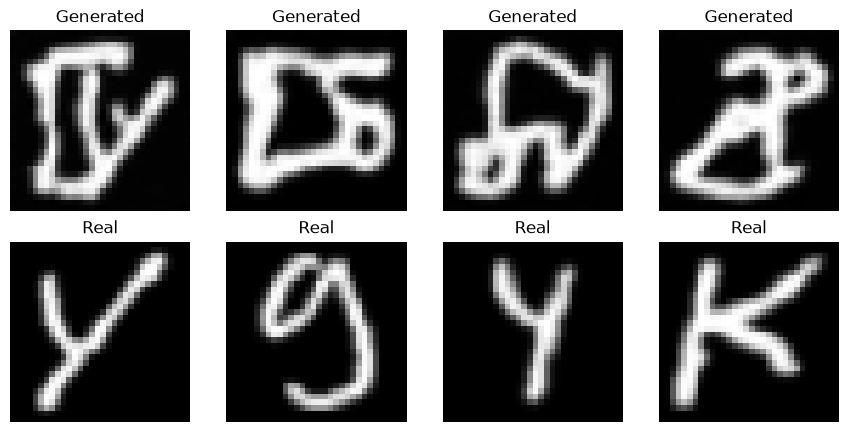

Saved generated-vs-real comparison to ./outputs_ddpm\generated_vs_real.png


In [17]:
real_images = compare_with_real(generated_images, real_images_ds, n_samples=4)


In [18]:
evaluate_psnr_ssim(generated_images, real_images)


Average PSNR: 6.715 dB
Average SSIM: 0.027


(6.715179302794062, 0.02708406653056824)

In [19]:
model.save_weights(os.path.join(OUT_DIR, "ddpm_unet_emnist.weights.h5"))
